# t-SNE (t-distributed Stochastic Neighbor Embedding) — UCI HAR Veri Seti Üzerinde Uygulama

Bu defter, t-SNE'yi UCI HAR (Human Activity Recognition) veri setine uygular.
Veri: 561 özellik, 6 aktivite sınıfı.

Konu anlatımı için aynı klasördeki `tsne_konu_anlatimi.md` dosyasına bakabilirsiniz.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

plt.rcParams['figure.dpi'] = 110
np.random.seed(42)


## 1. Veriyi Yükleme

In [2]:
DATA_DIR = "../data/UCI HAR Dataset"

X = pd.read_csv(f"{DATA_DIR}/train/X_train.txt", sep=r"\s+", header=None)
y = pd.read_csv(f"{DATA_DIR}/train/y_train.txt", sep=r"\s+", header=None)[0]
activity_labels = pd.read_csv(f"{DATA_DIR}/activity_labels.txt", sep=r"\s+", header=None, index_col=0)[1]
y_named = y.map(activity_labels)

print("X boyutu:", X.shape)
print(y_named.value_counts())


X boyutu: (7352, 561)
0
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


## 2. Ölçekleme (Standardization)

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Ölçeklenmiş veri şekli:", X_scaled.shape)


Ölçeklenmiş veri şekli: (7352, 561)


## 3. t-SNE ile 2 Boyuta İndirgeme

t-SNE hesaplama maliyeti yüksek olduğundan hız için 2000 örneklik bir alt küme kullanıyoruz.


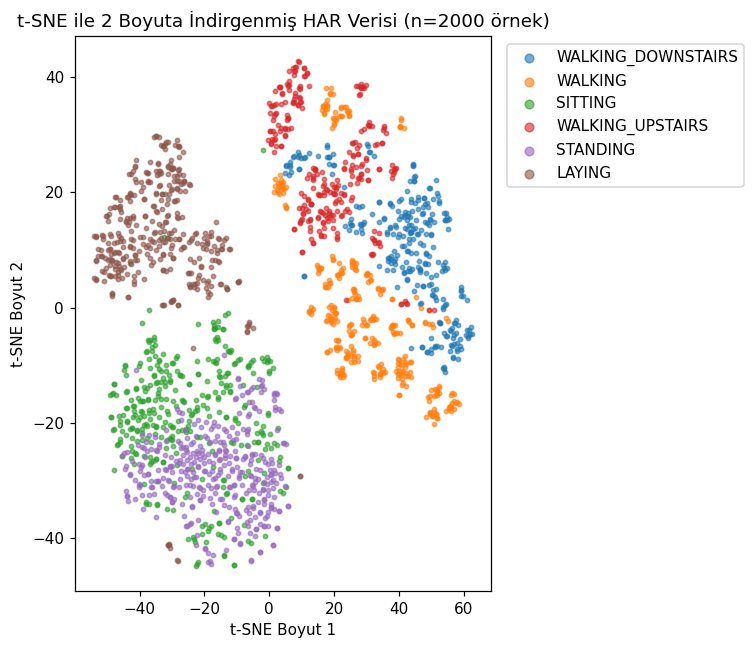

In [4]:
n_sample = 2000
idx = np.random.choice(X_scaled.shape[0], n_sample, replace=False)
X_sub = X_scaled[idx]
y_sub = y_named.iloc[idx].reset_index(drop=True)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_sub)

plt.figure(figsize=(7,6))
for label in y_sub.unique():
    mask = y_sub == label
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=8, alpha=0.6, label=label)
plt.xlabel("t-SNE Boyut 1")
plt.ylabel("t-SNE Boyut 2")
plt.title(f"t-SNE ile 2 Boyuta İndirgenmiş HAR Verisi (n={n_sample} örnek)")
plt.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 4. Yorum

t-SNE, PCA'ya kıyasla sınıfları genelde çok daha net ve kompakt kümeler halinde ayırır, çünkü doğrusal olmayan
yerel yapıyı yakalayabilir. Ancak eksenlerin (t-SNE Boyut 1/2) kendi başına bir anlamı yoktur; sadece kümeleme
yapısını yorumlamak için kullanılır — mesafeler ve küme boyutları global ölçekte güvenilir değildir.
